## Data Analysis

This notebook loads the data and analyzes the data to find interesting counts, aggregates, etc

In [1]:
import pandas as pd
import numpy as np

df_rests = pd.read_csv("restaurants_santa_barbara.csv", encoding="latin-1")
df_train = pd.read_csv("train_reviews_santa_barbara.csv", encoding="latin-1")
df_test  = pd.read_csv("test_reviews_santa_barbara.csv", encoding="latin-1")

df_train['stars'] = pd.to_numeric(df_train['stars'])
df_test['stars']  = pd.to_numeric(df_test['stars'])

### Basic dataset counts

In [2]:
print("Dataset Overview")
print(f"Total restaurants:              {len(df_rests)}")
print(f"Total training reviews:         {len(df_train)}")
print(f"Total test reviews:             {len(df_test)}")
print(f"Unique users (train):           {df_train['user_id'].nunique()}")
print(f"Unique users (test):            {df_test['user_id'].nunique()}")
print(f"Unique restaurants (train):     {df_train['business_id'].nunique()}")
print(f"Restaurants with no reviews:    {len(df_rests) - df_train['business_id'].nunique()}")

Dataset Overview
Total restaurants:              767
Total training reviews:         41581
Total test reviews:             4801
Unique users (train):           4801
Unique users (test):            4801
Unique restaurants (train):     694
Restaurants with no reviews:    73


### Rating distribution

In [4]:
rating_counts = df_train['stars'].value_counts().sort_index()
print("Rating Distribution")
for star, count in rating_counts.items():
    print(f"  {star} stars: {count:,}  ({count/len(df_train)*100:.1f}%)")
print(f"\nMean rating:   {df_train['stars'].mean():.2f}")
print(f"Median rating: {df_train['stars'].median():.1f}")

Rating Distribution
  1.0 stars: 2,412  (5.8%)
  2.0 stars: 3,149  (7.6%)
  3.0 stars: 5,498  (13.2%)
  4.0 stars: 12,446  (29.9%)
  5.0 stars: 18,076  (43.5%)

Mean rating:   3.98
Median rating: 4.0


### Plot of rating distributions

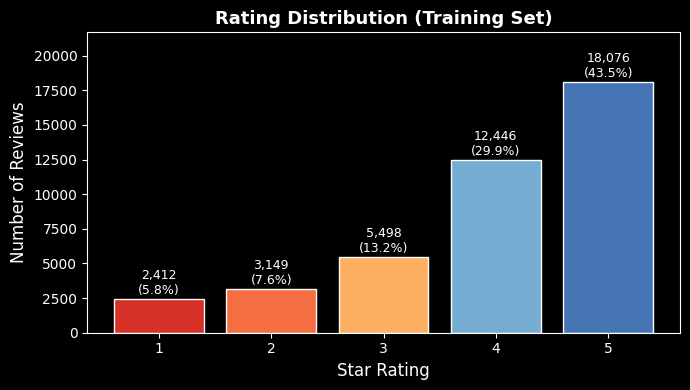

In [13]:
import matplotlib.pyplot as plt

rating_counts = df_train['stars'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#4575b4']
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white')

for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{count:,}\n({count/len(df_train)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Rating Distribution (Training Set)', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, rating_counts.max() * 1.2)
plt.tight_layout()
plt.show()

### Reviews per user

In [6]:
reviews_per_user = df_train.groupby('user_id').size()
print("Reviews Per User")
print(f"  Min:    {reviews_per_user.min()}")
print(f"  Max:    {reviews_per_user.max()}")
print(f"  Mean:   {reviews_per_user.mean():.1f}")
print(f"  Median: {reviews_per_user.median():.0f}")
print(f"\nUsers with only 1 review:    {(reviews_per_user == 1).sum()}")
print(f"Users with 5 or fewer:       {(reviews_per_user <= 5).sum()}")
print(f"Users with 10 or more:       {(reviews_per_user >= 10).sum()}")

Reviews Per User
  Min:    1
  Max:    152
  Mean:   8.7
  Median: 6

Users with only 1 review:    3
Users with 5 or fewer:       2314
Users with 10 or more:       1102


### Reviews per restaurant

In [7]:
reviews_per_rest = df_train.groupby('business_id').size()
print("Reviews Per Restaurant")
print(f"  Min:    {reviews_per_rest.min()}")
print(f"  Max:    {reviews_per_rest.max()}")
print(f"  Mean:   {reviews_per_rest.mean():.1f}")
print(f"  Median: {reviews_per_rest.median():.0f}")
print(f"\nRestaurants with fewer than 5 reviews:  {(reviews_per_rest < 5).sum()}")
print(f"Restaurants with fewer than 10 reviews: {(reviews_per_rest < 10).sum()}")
print(f"Restaurants with 100+ reviews:          {(reviews_per_rest >= 100).sum()}")

Reviews Per Restaurant
  Min:    1
  Max:    670
  Mean:   59.9
  Median: 35

Restaurants with fewer than 5 reviews:  46
Restaurants with fewer than 10 reviews: 124
Restaurants with 100+ reviews:          132


### Top Categories

In [10]:
from collections import Counter

cats = df_rests['categories'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')]
)
all_cats = Counter(c for sublist in cats for c in sublist if c)
top_cats = pd.Series(all_cats).sort_values(ascending=False)

print("Top 20 Categories")
print(top_cats.head(20).to_string())
print(f"\nTotal unique categories: {len(top_cats)}")

Top 20 Categories
restaurants                  767
food                         259
nightlife                    173
bars                         158
american (new)               151
breakfast & brunch           119
mexican                      118
sandwiches                   103
american (traditional)        95
seafood                       78
coffee & tea                  74
pizza                         71
event planning & services     59
cafes                         58
burgers                       57
delis                         56
salad                         56
italian                       55
bakeries                      49
cocktail bars                 49

Total unique categories: 224


### Plot of top categories

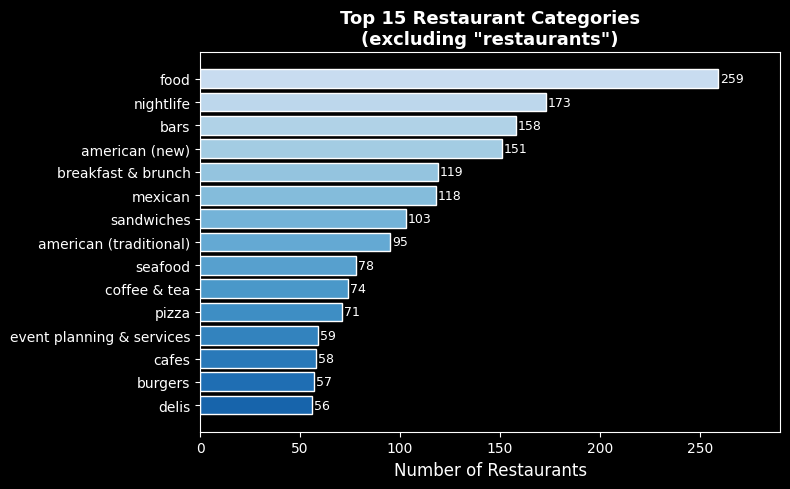

In [14]:
top15 = top_cats.drop('restaurants', errors='ignore').head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Blues_r([i / len(top15) * 0.6 + 0.2 for i in range(len(top15))])
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors, edgecolor='white')

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Restaurants', fontsize=12)
ax.set_title('Top 15 Restaurant Categories\n(excluding "restaurants")', fontsize=13, fontweight='bold')
ax.set_xlim(0, top15.max() * 1.12)
plt.tight_layout()
plt.show()

### Price range distribution

In [12]:
import ast

def str_to_dict(s):
    try: return ast.literal_eval(s)
    except: return {}

def clean_values(d):
    return {k: (v.strip("'\"") if isinstance(v, str) else v) for k, v in d.items()}

df_rests['attr'] = df_rests['attributes'].apply(str_to_dict).apply(clean_values)
df_rests['price'] = df_rests['attr'].apply(
    lambda d: d.get('RestaurantsPriceRange2', 'unknown')
)

print("Price Range Distribution")
price_counts = df_rests['price'].value_counts()
for level, count in price_counts.items():
    print(f"  Level {level}: {count} restaurants ({count/len(df_rests)*100:.1f}%)")


Price Range Distribution
  Level 2: 433 restaurants (56.5%)
  Level 1: 190 restaurants (24.8%)
  Level unknown: 77 restaurants (10.0%)
  Level 3: 57 restaurants (7.4%)
  Level 4: 9 restaurants (1.2%)
  Level None: 1 restaurants (0.1%)
